# 1.2 — Stability and Robustness of Automatically Generated CAV Datasets

In [1]:
!pip install -q torch torchvision scikit-learn numpy matplotlib seaborn tqdm scipy Pillow

In [2]:
import os, random, warnings, itertools
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, Dataset

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')


Device : cuda
PyTorch: 2.10.0+cu128


## Model Layer Configuration

Must be defined **before** `Config` so the dataclass can reference it at init time.


In [3]:
MODEL_LAYERS = {
    'resnet50': [
        'layer1.2', 'layer2.3', 'layer3.5', 'layer4.2',
    ],
    'inception_v3': [
        'Mixed_5d', 'Mixed_6c', 'Mixed_6e', 'Mixed_7c',
    ],
    'vgg16': [
        'features.8', 'features.15', 'features.22', 'features.29',
    ],
}
print('MODEL_LAYERS defined:', list(MODEL_LAYERS.keys()))


MODEL_LAYERS defined: ['resnet50', 'inception_v3', 'vgg16']


## Model Selection

Set `MODEL_NAME` to one of `'resnet50'`, `'vgg16'`, `'inception_v3'`.


In [4]:
# ─── Choose ONE backbone ─────────────────────────────────────────────────────
MODEL_NAME = 'resnet50'          # 'resnet50' | 'vgg16' | 'inception_v3'

assert MODEL_NAME in MODEL_LAYERS, f'Unsupported model: {MODEL_NAME}'
print(f'Model selected : {MODEL_NAME}')
print(f'Target layers  : {MODEL_LAYERS[MODEL_NAME]}')


Model selected : resnet50
Target layers  : ['layer1.2', 'layer2.3', 'layer3.5', 'layer4.2']


## Configuration


In [5]:
@dataclass
class Config:
    model_name:         str       = 'resnet50'
    cav_classifier:     str       = 'difference_of_means'  # | 'logistic' | 'svm'

    # ── Negatives & standardization (allineati a tesi §3.1 / §3.5 / §1.5) ──────
    negative_source:    str       = 'imagenet'  # 'imagenet' (tesi) | 'dtd' (deliberato)
    standardize:        bool      = True         # shared-negative StandardScaler
    n_random_negatives: int       = 500          # dimensione del POOL NEGATIVO CONDIVISO

    concept_names:      List[str] = field(default_factory=list)
    # Exp 1 (stabilità su negativi random)
    n_random_trials:    int       = 20
    n_concept_samples:  int       = 30
    n_negative_samples: int       = 30
    # Exp 2 (stabilità vs dimensione dataset)
    size_range:         List[int] = field(default_factory=lambda: [10, 20, 50, 75, 100, 150, 200])
    n_size_trials:      int       = 10
    # Exp 3 (intra-similarity)
    target_layers:      List[str] = field(default_factory=list)
    n_intra_trials:     int       = 30
    # Misc
    batch_size:         int       = 64
    img_size:           int       = 224


cfg = Config()
cfg.model_name    = MODEL_NAME
cfg.target_layers = MODEL_LAYERS[MODEL_NAME]
cfg.img_size      = 299 if MODEL_NAME == 'inception_v3' else 224

print('Configuration loaded')
print(f'  backbone        : {cfg.model_name}')
print(f'  CAV method      : {cfg.cav_classifier}')
print(f'  target layers   : {cfg.target_layers}')
print(f'  image size      : {cfg.img_size}')
print(f'  negative source : {cfg.negative_source}')
print(f'  standardize     : {cfg.standardize}  (shared-negative scaler)')
print(f'  shared neg pool : {cfg.n_random_negatives}')


Configuration loaded
  backbone        : resnet50
  CAV method      : difference_of_means
  target layers   : ['layer1.2', 'layer2.3', 'layer3.5', 'layer4.2']
  image size      : 224
  negative source : imagenet
  standardize     : True  (shared-negative scaler)
  shared neg pool : 500


## Feature Extractor

Hook-based extractor supporting **ResNet50**, **VGG16**, and **InceptionV3**.


In [6]:
class FeatureExtractor(nn.Module):
    """
    Extracts intermediate activations via forward hooks.
    Supports: resnet50, vgg16, inception_v3.
    """

    def __init__(self, model_name: str = 'resnet50', layers: List[str] = None):
        super().__init__()
        assert model_name in MODEL_LAYERS, f'Unsupported model: {model_name}'
        self.model_name = model_name

        if model_name == 'resnet50':
            self.model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        elif model_name == 'vgg16':
            self.model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        elif model_name == 'inception_v3':
            self.model = models.inception_v3(
                weights=models.Inception_V3_Weights.IMAGENET1K_V1
                # aux_logits NON va passato qui: i pesi pretrained lo forzano a True
            )
            # Disabilita il ramo ausiliario DOPO il caricamento dei pesi
            self.model.aux_logits = False
            self.model.AuxLogits  = None

        self.model.eval()
        self.layers  = layers or MODEL_LAYERS[model_name]
        self._hooks: List = []
        self._features: Dict[str, torch.Tensor] = {}
        self._register_hooks()

    def _get_module(self, layer_name: str):
        """Resolves dotted paths like 'features.16'."""
        module = self.model
        for part in layer_name.split('.'):
            module = module[int(part)] if part.isdigit() else getattr(module, part)
        return module

    def _register_hooks(self):
        for name in self.layers:
            handle = self._get_module(name).register_forward_hook(self._make_hook(name))
            self._hooks.append(handle)

    def _make_hook(self, name: str):
        def hook(module, inp, out):
            self._features[name] = (out[0] if isinstance(out, tuple) else out).detach()
        return hook

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        self._features = {}
        with torch.no_grad():
            _ = self.model(x)
        pooled = {}
        for name, feat in self._features.items():
            if feat.ndim == 4:               # spatial tensor → global avg pool
                feat = feat.mean(dim=(2, 3))
            pooled[name] = feat.cpu()
        return pooled

    def remove_hooks(self):
        for h in self._hooks:
            h.remove()


# ── Quick sanity check ────────────────────────────────────────────────────────
_dummy = torch.zeros(2, 3, cfg.img_size, cfg.img_size)
_fx    = FeatureExtractor(cfg.model_name, cfg.target_layers)
_out   = _fx(_dummy)
print(f'FeatureExtractor ({cfg.model_name}) output shapes:')
for k, v in _out.items():
    print(f'  {k:<22}: {tuple(v.shape)}')
_fx.remove_hooks()
del _fx, _dummy, _out


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


FeatureExtractor (resnet50) output shapes:
  layer1.2              : (2, 256)
  layer2.3              : (2, 512)
  layer3.5              : (2, 1024)
  layer4.2              : (2, 2048)


## Dataset Paths & Constants


In [7]:
ACG_NEW  = '/kaggle/input/datasets/alessandrocogollo/acg4cav-base-extraction/dataset'

CROP_METHODS = ['bbox', 'center_mask', 'largest_bbox', 'sliding_window']
SPLITS       = ['single', 'multi', 'random']

DTD_ROOT  = '/kaggle/input/datasets/alessandrocogollo/vtcav-dataset/DTD-Concept'
DTD2_ROOT = '/kaggle/input/datasets/jmexpert/describable-textures-dataset-dtd/dtd/images'
T2I_ROOT  = '/kaggle/input/datasets/alessandrocogollo/zeroshot-t2i-concepts/concepts'

IMAGENET_ROOT_CANDIDATES = [
    '/kaggle/input/datasets/alessandrocogollo/vtcav-dataset/random',
    '/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val',
    '/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train',
    '/kaggle/input/ilsvrc/Data/CLS-LOC/val',
    '/kaggle/input/imagenet1kvalid/imagenet_validation',
    '/kaggle/input/imagenet-1k-valid-set/val',
]
IMAGENET_ROOT = next((p for p in IMAGENET_ROOT_CANDIDATES if Path(p).is_dir()),
                     IMAGENET_ROOT_CANDIDATES[0])
print(f'IMAGENET_ROOT -> {IMAGENET_ROOT}  (exists={Path(IMAGENET_ROOT).is_dir()})')

CONCEPT_SPLIT_OVERRIDE: Dict[str, str] = {}

MANUAL_BASELINE: Dict[str, str] = {
    'striped':   f'{DTD_ROOT}/striped',
    'dotted':    f'{DTD_ROOT}/dotted',
    'chequered': f'{DTD_ROOT}/chequered',
    'wood':      f'{T2I_ROOT}/wood/wood',
    'water':     f'{T2I_ROOT}/water/water',
    'braided':   f'{DTD_ROOT}/braided',
    'bubbly':    f'{T2I_ROOT}/bubbly/bubbly',
    'fibrous':   f'{DTD_ROOT}/fibrous',
    'veined':    f'{DTD_ROOT}/veined',
}

ALL_CONCEPTS  = ['striped', 'dotted', 'chequered', 'wood', 'water', 'braided', 'bubbly', 'fibrous', 'veined']

print(f'Concepts: {ALL_CONCEPTS}')

IMAGENET_ROOT -> /kaggle/input/datasets/alessandrocogollo/vtcav-dataset/random  (exists=True)
Concepts: ['striped', 'dotted', 'chequered', 'wood', 'water', 'braided', 'bubbly', 'fibrous', 'veined']


In [8]:
def build_mapping_auto_vanilla(
    concepts: List[str],
    crop_method: str,
    split: str,
) -> Dict[str, Dict[str, str]]:
    aug_root = f'{ACG_NEW}/augmented/augmented_{crop_method}'
    van_root = f'{ACG_NEW}/vanilla/vanilla_{crop_method}'
    return {
        c: {
            'augmented':    f'{aug_root}/{c}/{CONCEPT_SPLIT_OVERRIDE.get(c, split)}',
            'vanilla': f'{van_root}/{c}/{CONCEPT_SPLIT_OVERRIDE.get(c, split)}',
        }
        for c in concepts
    }


def build_mapping_manual(concepts: List[str]) -> Dict[str, Dict[str, str]]:
    return {c: {'manual': MANUAL_BASELINE[c]} for c in concepts}


def merge_concept_mappings(auto_mapping: Dict, manual_mapping: Dict) -> Dict:
    merged = {}
    for concept in auto_mapping:
        merged[concept] = {}
        merged[concept].update(auto_mapping[concept])
        if concept in manual_mapping:
            merged[concept].update(manual_mapping[concept])
    return merged


print('Mapping builders defined')

Mapping builders defined


## Dataset Loading

Builds `full_dataset`, `concept_pool`, and `negative_pool` from the path mappings.

Edit `ACTIVE_CROP`, `ACTIVE_SPLIT`, and `ACTIVE_DATASET_TYPE` as needed.

In [9]:
# Active configuration
ACTIVE_CONCEPTS     = ALL_CONCEPTS  # oppure un sottoinsieme
ACTIVE_CROP         = 'sliding_window'   # one of CROP_METHODS
ACTIVE_SPLIT        = 'single'           # one of SPLITS
ACTIVE_DATASET_TYPE = 'vanilla'          # 'augmented' | 'vanilla' | 'manual'

# Build mappings
_auto_map       = build_mapping_auto_vanilla(ACTIVE_CONCEPTS, ACTIVE_CROP, ACTIVE_SPLIT)
_manual_map     = build_mapping_manual(ACTIVE_CONCEPTS)
concept_mapping = merge_concept_mappings(_auto_map, _manual_map)

# Per-model transforms
_transform = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class SimpleImageDataset(Dataset):
    """Flat list of (image_path, label) pairs."""
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# Collect concept images
_IMG_EXTS = ('*.jpg', '*.jpeg', '*.png', '*.JPEG', '*.JPG', '*.PNG')

def _glob_images(directory):
    p = Path(directory)
    out = []
    for ext in _IMG_EXTS:
        out.extend(p.glob(ext))
    return [str(x) for x in sorted(out)]


all_paths    = []
all_labels   = []
concept_pool = {}

print(f'Loading concepts  [{ACTIVE_DATASET_TYPE} / {ACTIVE_CROP} / {ACTIVE_SPLIT}]...')
for i, concept in enumerate(ACTIVE_CONCEPTS):
    src_dir = concept_mapping[concept][ACTIVE_DATASET_TYPE]
    imgs    = _glob_images(src_dir)
    if not imgs:
        print(f'  WARNING: {concept}: 0 images found in {src_dir}')
    start = len(all_paths)
    all_paths.extend(imgs)
    all_labels.extend([i + 1] * len(imgs))      # label 0 = negativi
    concept_pool[concept] = list(range(start, len(all_paths)))
    print(f'  {concept:<14}: {len(imgs):>5} images')

# Collect NEGATIVES
if cfg.negative_source == 'imagenet':
    _neg_root = IMAGENET_ROOT
elif cfg.negative_source == 'dtd':
    _neg_root = DTD2_ROOT
else:
    raise ValueError(f"cfg.negative_source deve essere 'imagenet' o 'dtd', non {cfg.negative_source!r}")

print(f'\nLoading negatives [{cfg.negative_source}] from: {_neg_root}')
_neg_all = []
for ext in _IMG_EXTS:
    _neg_all.extend(str(p) for p in Path(_neg_root).rglob(ext))

_concept_dirs = set()
for c in ACTIVE_CONCEPTS:
    for v in concept_mapping[c].values():
        _concept_dirs.add(os.path.abspath(v))
_concept_dirs = tuple(_concept_dirs)
_before  = len(_neg_all)
_neg_all = [p for p in _neg_all if not os.path.abspath(p).startswith(_concept_dirs)]
_removed = _before - len(_neg_all)
if _removed:
    print(f'  Excluded {_removed} negative paths overlapping concept directories')

if len(_neg_all) == 0:
    raise FileNotFoundError(
        f"Nessuna immagine negativa trovata sotto {_neg_root!r}.\n"
        f"  - Per negativi ImageNet (tesi §3.1/§3.5): imposta IMAGENET_ROOT su una "
        f"cartella ImageNet collegata a questo notebook Kaggle.\n"
        f"  - Per usare DTD di proposito: cfg.negative_source = 'dtd'."
    )

random.shuffle(_neg_all)
_neg_selected = _neg_all[: cfg.n_random_negatives * 5]

_neg_start    = len(all_paths)
all_paths.extend(_neg_selected)
all_labels.extend([0] * len(_neg_selected))
negative_pool = list(range(_neg_start, len(all_paths)))
print(f'  Negative pool: {len(negative_pool)} images (source={cfg.negative_source})')

# Build dataset & update config
full_dataset      = SimpleImageDataset(all_paths, all_labels, transform=_transform)
cfg.concept_names = ACTIVE_CONCEPTS

print(f'\nfull_dataset size  : {len(full_dataset)}')
print(f'concept_names      : {cfg.concept_names}')
print(f'negative_pool size : {len(negative_pool)}')

Loading concepts  [vanilla / sliding_window / single]...
  striped       :   100 images
  dotted        :   100 images
  chequered     :   100 images
  wood          :   100 images
  water         :   100 images
  braided       :   100 images
  bubbly        :   100 images
  fibrous       :   100 images
  veined        :   100 images

Loading negatives [imagenet] from: /kaggle/input/datasets/alessandrocogollo/vtcav-dataset/random
  Negative pool: 1496 images (source=imagenet)

full_dataset size  : 2396
concept_names      : ['striped', 'dotted', 'chequered', 'wood', 'water', 'braided', 'bubbly', 'fibrous', 'veined']
negative_pool size : 1496


## Activation Extraction Utilities


In [10]:
def extract_activations(indices, layers=None):
    """
    Extract activations at each target layer for the given dataset indices.
    Returns {layer_name: ndarray of shape (N, D)}.
    """
    layers = layers or cfg.target_layers
    if len(indices) == 0:
        return {l: np.array([]) for l in layers}

    subset = Subset(full_dataset, indices)
    loader = DataLoader(subset, batch_size=cfg.batch_size,
                        shuffle=False, num_workers=2, pin_memory=True)

    layer_acts = {l: [] for l in layers}
    extractor  = FeatureExtractor(cfg.model_name, layers).to(DEVICE)
    for imgs, _ in loader:
        feats = extractor(imgs.to(DEVICE))
        for l in layers:
            layer_acts[l].append(feats[l].numpy())
    extractor.remove_hooks()

    result = {}
    for l, v in layer_acts.items():
        result[l] = np.concatenate(v, axis=0) if len(v) else np.array([])
    return result


# Pre-compute concept activations
print('Pre-computing concept activations...')
concept_acts = {}
missing_concepts = []
for concept_name, indices in tqdm(concept_pool.items(), desc='Concepts'):
    acts = extract_activations(indices[:300])
    concept_acts[concept_name] = acts
    if acts[cfg.target_layers[0]].size == 0:
        missing_concepts.append(concept_name)
        print(f'  WARN {concept_name}: no activations extracted (0 images?)')

if missing_concepts:
    print(f'\nRemoving concepts with no images: {missing_concepts}')
    for c in missing_concepts:
        del concept_acts[c]; del concept_pool[c]
    cfg.concept_names = [c for c in cfg.concept_names if c not in missing_concepts]
    print(f'   Remaining concepts: {cfg.concept_names}')

# Pre-compute the SHARED negative pool activations
print('\nPre-computing negative activations (shared pool)...')
_neg_sample   = random.sample(negative_pool, min(cfg.n_random_negatives, len(negative_pool)))
negative_acts = extract_activations(_neg_sample)

negative_scalers: Dict[str, Optional[StandardScaler]] = {}
if cfg.standardize:
    for layer in cfg.target_layers:
        negative_scalers[layer] = StandardScaler().fit(negative_acts[layer])
    _nneg = len(negative_acts[cfg.target_layers[0]])
    print(f'Shared-negative scalers fitted on {_nneg} negatives per layer')
else:
    negative_scalers = {layer: None for layer in cfg.target_layers}
    print('Standardization disabled (cfg.standardize=False)')

print('\nActivations ready')
for concept in cfg.concept_names:
    shapes = {l: concept_acts[concept][l].shape for l in cfg.target_layers}
    print(f'  {concept:<14}: {shapes}')

Pre-computing concept activations...


Concepts:   0%|          | 0/9 [00:00<?, ?it/s]


Pre-computing negative activations (shared pool)...
Shared-negative scalers fitted on 500 negatives per layer

Activations ready
  striped       : {'layer1.2': (100, 256), 'layer2.3': (100, 512), 'layer3.5': (100, 1024), 'layer4.2': (100, 2048)}
  dotted        : {'layer1.2': (100, 256), 'layer2.3': (100, 512), 'layer3.5': (100, 1024), 'layer4.2': (100, 2048)}
  chequered     : {'layer1.2': (100, 256), 'layer2.3': (100, 512), 'layer3.5': (100, 1024), 'layer4.2': (100, 2048)}
  wood          : {'layer1.2': (100, 256), 'layer2.3': (100, 512), 'layer3.5': (100, 1024), 'layer4.2': (100, 2048)}
  water         : {'layer1.2': (100, 256), 'layer2.3': (100, 512), 'layer3.5': (100, 1024), 'layer4.2': (100, 2048)}
  braided       : {'layer1.2': (100, 256), 'layer2.3': (100, 512), 'layer3.5': (100, 1024), 'layer4.2': (100, 2048)}
  bubbly        : {'layer1.2': (100, 256), 'layer2.3': (100, 512), 'layer3.5': (100, 1024), 'layer4.2': (100, 2048)}
  fibrous       : {'layer1.2': (100, 256), 'layer2.

## CAV Training Core


In [11]:
def train_cav(
    pos_acts,
    neg_acts,
    classifier='difference_of_means',
    return_accuracy=False,
    scaler=None,
):
    """
    Compute a CAV from positive (concept) and negative activations.

    Se `scaler` (StandardScaler fittato sul POOL NEGATIVO CONDIVISO) e' fornito,
    positivi e negativi vengono trasformati prima del calcolo -- per OGNI metodo,
    difference-of-means incluso (tesi §3.5: "the scaler is fit on the shared
    negative pool and then applied").

    Methods
    -------
    difference_of_means (default)  CAV = normalise(mean(pos) - mean(neg))
    logistic / svm                 CAV = unit-normalised weight vector
    """
    # Shared-negative standardization
    if scaler is not None:
        pos_acts = scaler.transform(pos_acts)
        neg_acts = scaler.transform(neg_acts)

    X = np.concatenate([pos_acts, neg_acts], axis=0)
    y = np.array([1] * len(pos_acts) + [0] * len(neg_acts))

    if classifier == 'difference_of_means':
        diff = pos_acts.mean(0) - neg_acts.mean(0)
        cav  = diff / (np.linalg.norm(diff) + 1e-12)
        acc  = None
        if return_accuracy:
            proj      = X @ cav            # X gia' nello spazio scalato se scaler!=None
            threshold = 0.5 * (proj[y == 1].mean() + proj[y == 0].mean())
            acc       = float(np.mean((proj > threshold).astype(int) == y))
        return cav, acc

    # logistic / svm
    if scaler is None:
        X = StandardScaler().fit_transform(X)

    if classifier == 'logistic':
        clf = LogisticRegression(max_iter=1000, C=1.0, random_state=GLOBAL_SEED)
    elif classifier == 'svm':
        clf = LinearSVC(max_iter=2000, C=1.0, random_state=GLOBAL_SEED)
    else:
        raise ValueError(f'Unknown classifier: {classifier}')

    acc = float(cross_val_score(clf, X, y, cv=5).mean()) if return_accuracy else None
    clf.fit(X, y)
    w   = clf.coef_[0] if clf.coef_.ndim == 2 else clf.coef_
    cav = w / (np.linalg.norm(w) + 1e-12)
    return cav, acc


def cosine_similarity(a, b):
    return 1.0 - float(cosine(a, b))


def pairwise_cosine(vectors):
    """All unique pairwise cosine similarities as a 1-D array."""
    return np.array([
        cosine_similarity(vectors[i], vectors[j])
        for i, j in itertools.combinations(range(len(vectors)), 2)
    ])


print(f'CAV utilities defined  (method = {cfg.cav_classifier}, standardize = {cfg.standardize})')

CAV utilities defined  (method = difference_of_means, standardize = True)


---
## Experiment A — Stability Across Random Samples

In [12]:
print('EXPERIMENT 1 - Stability Across Random NEGATIVE Samples')

neg_pool_n = len(negative_acts[cfg.target_layers[0]])
assert neg_pool_n >= 3, f'Pool negativo troppo piccolo ({neg_pool_n}).'
neg_m = min(cfg.n_negative_samples, neg_pool_n - 1)   # m < N (anti-degenerazione)

exp1_results = {}
for concept in cfg.concept_names:
    exp1_results[concept] = {
        'cavs': {l: [] for l in cfg.target_layers},
        'accs': {l: [] for l in cfg.target_layers},
    }
    pool_size = len(concept_acts[concept][cfg.target_layers[0]])
    pos_m     = min(cfg.n_concept_samples, pool_size)
    pos_idx   = np.random.choice(pool_size, size=pos_m, replace=False)  # fisso per concetto

    for trial in tqdm(range(cfg.n_random_trials), desc=f'  {concept}', leave=False):
        neg_idx = np.random.choice(neg_pool_n, size=neg_m, replace=False)
        for layer in cfg.target_layers:
            cav, acc = train_cav(
                concept_acts[concept][layer][pos_idx],
                negative_acts[layer][neg_idx],
                cfg.cav_classifier, return_accuracy=(trial == 0),
                scaler=negative_scalers[layer],
            )
            exp1_results[concept]['cavs'][layer].append(cav)
            exp1_results[concept]['accs'][layer].append(acc)

exp1_similarity = {
    concept: {
        layer: pairwise_cosine(exp1_results[concept]['cavs'][layer])
        for layer in cfg.target_layers
    }
    for concept in cfg.concept_names
}

print('\nExp 1 - Mean Pairwise Cosine Similarity:')
print(f'{"Concept":<14}', end='')
for l in cfg.target_layers:
    print(f'{l:>22}', end='')
print()
for concept in cfg.concept_names:
    print(f'{concept:<14}', end='')
    for l in cfg.target_layers:
        print(f'{exp1_similarity[concept][l].mean():>22.4f}', end='')
    print()


EXPERIMENT 1 - Stability Across Random NEGATIVE Samples


  striped:   0%|          | 0/20 [00:00<?, ?it/s]

  dotted:   0%|          | 0/20 [00:00<?, ?it/s]

  chequered:   0%|          | 0/20 [00:00<?, ?it/s]

  wood:   0%|          | 0/20 [00:00<?, ?it/s]

...

  braided:   0%|          | 0/20 [00:00<?, ?it/s]

  bubbly:   0%|          | 0/20 [00:00<?, ?it/s]

  fibrous:   0%|          | 0/20 [00:00<?, ?it/s]

  veined:   0%|          | 0/20 [00:00<?, ?it/s]


Exp 1 - Mean Pairwise Cosine Similarity:
Concept                     layer1.2              layer2.3              layer3.5              layer4.2
striped                       0.9647                0.9646                0.9698                0.9524
dotted                        0.9201                0.9513                0.9664                0.9438
chequered                     0.9268                0.9601                0.9730                0.9432
wood                          0.9208                0.9386                0.9400                0.9148
water                         0.9496                0.9661                0.9413                0.9172
braided                       0.9287                0.9493                0.9374                0.7629
bubbly                        0.9282                0.9350                0.9419                0.9316
fibrous                       0.9663                0.9700                0.9608                0.9431
veined                        0

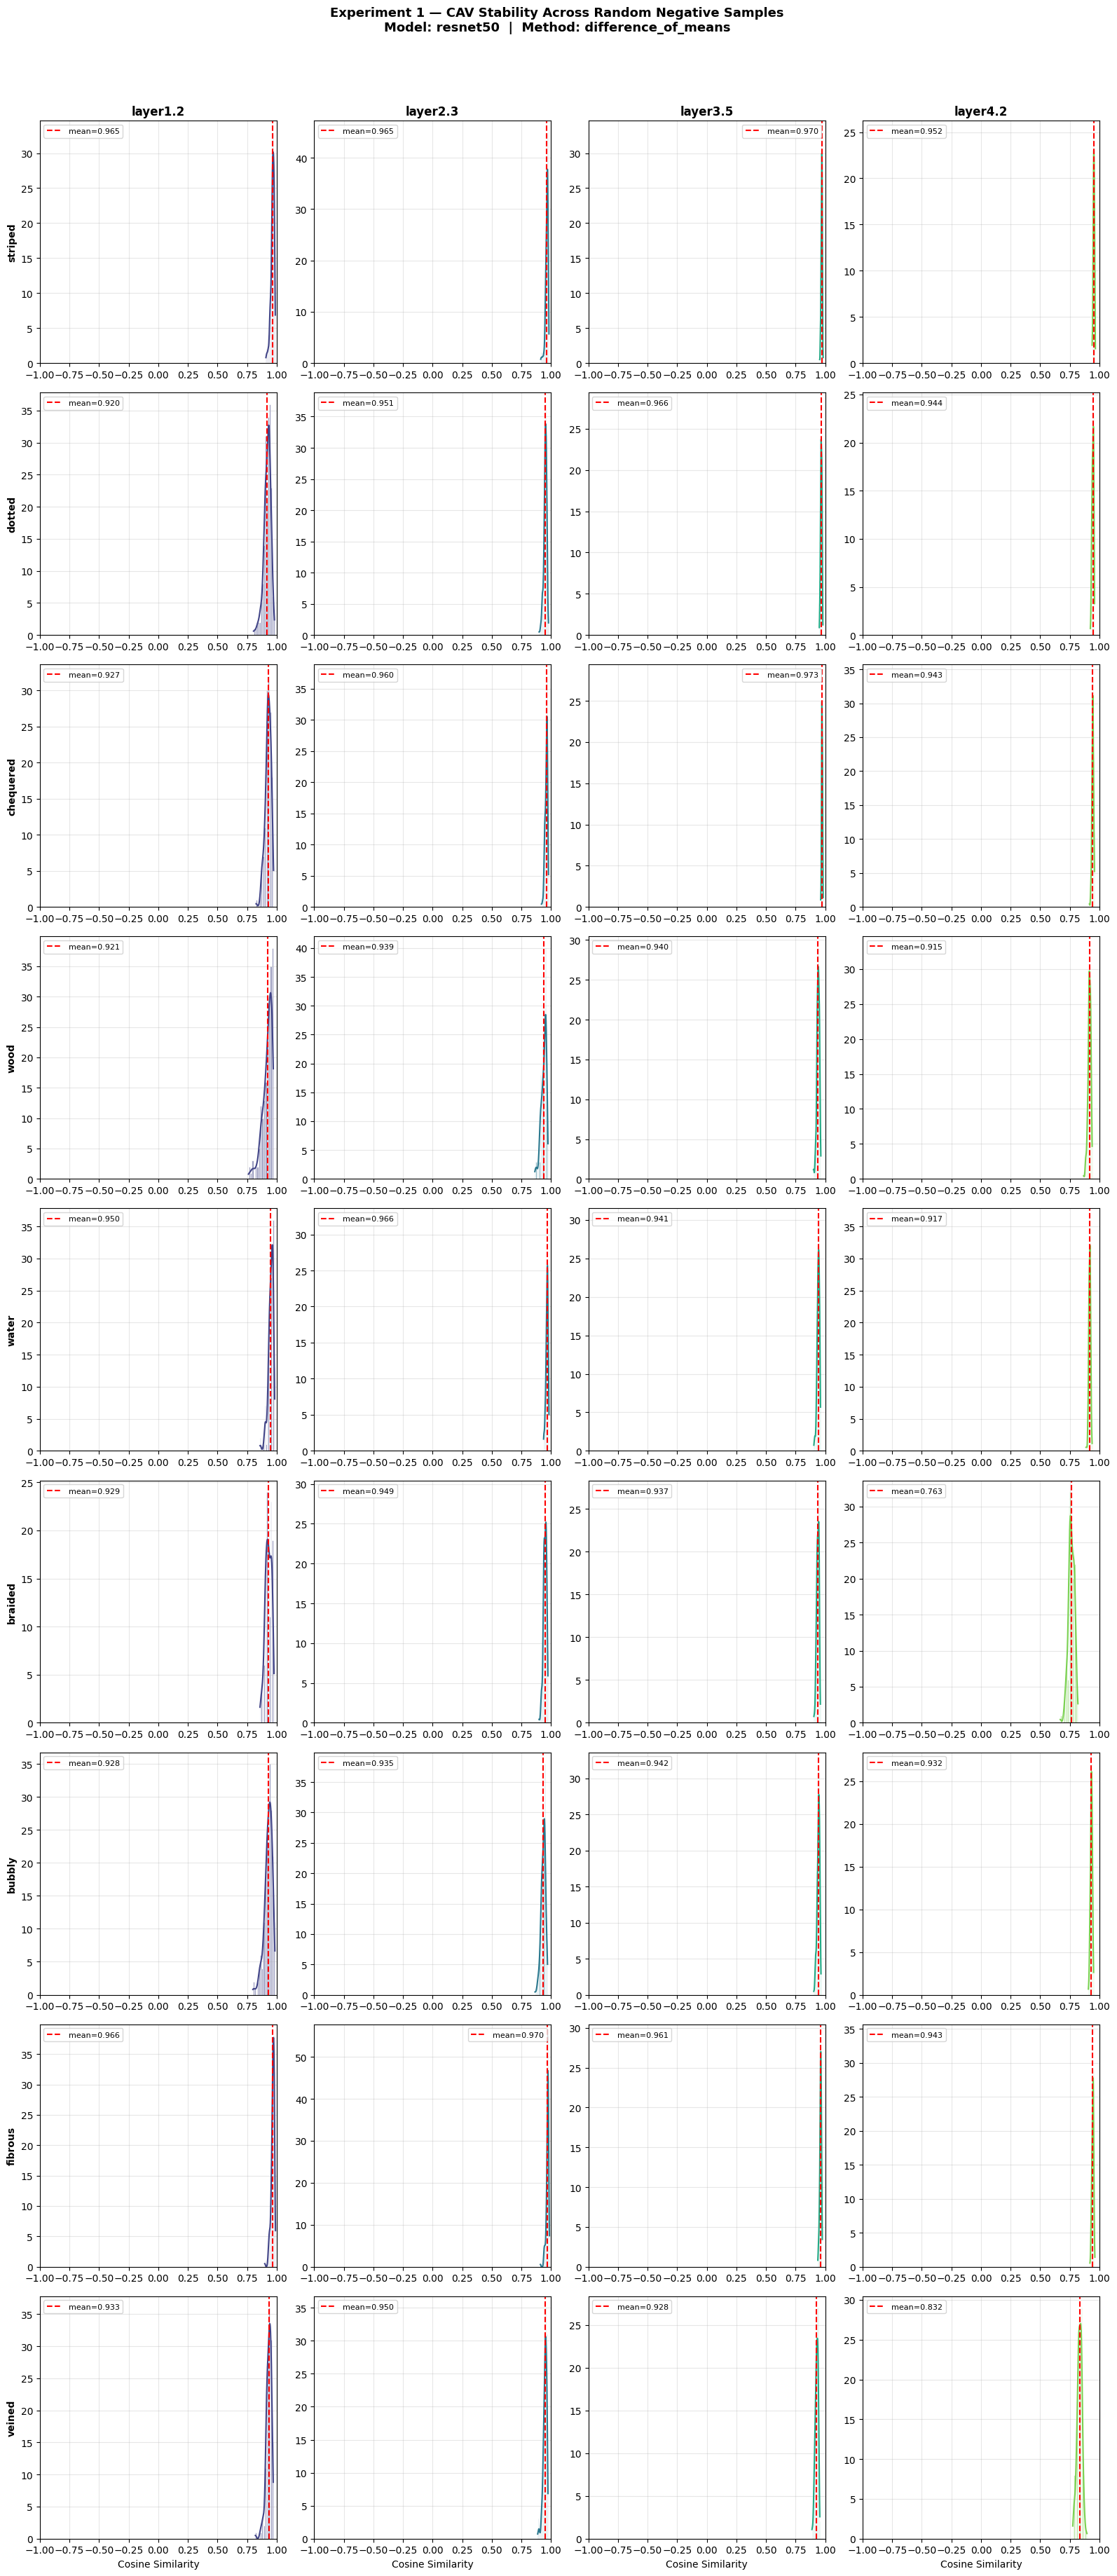

Figure saved.


In [13]:
fig, axes = plt.subplots(
    len(cfg.concept_names), len(cfg.target_layers),
    figsize=(4 * len(cfg.target_layers), 4 * len(cfg.concept_names)),
    squeeze=False,
)
fig.suptitle(
    f'Experiment 1 — CAV Stability Across Random Negative Samples\n'
    f'Model: {cfg.model_name}  |  Method: {cfg.cav_classifier}',
    fontsize=13, fontweight='bold', y=1.02,
)
palette = sns.color_palette('viridis', len(cfg.target_layers))

for i, concept in enumerate(cfg.concept_names):
    for j, layer in enumerate(cfg.target_layers):
        ax   = axes[i][j]
        sims = exp1_similarity[concept][layer]
        sns.histplot(sims, bins=15, kde=True, color=palette[j],
                     ax=ax, edgecolor='white', linewidth=0.5)
        ax.axvline(sims.mean(), color='red', linestyle='--', lw=1.5,
                   label=f'mean={sims.mean():.3f}')
        ax.set_xlim([-1, 1])
        ax.set_xlabel('Cosine Similarity' if i == len(cfg.concept_names) - 1 else '')
        ax.set_ylabel(concept if j == 0 else '', fontweight='bold')
        ax.set_title(layer if i == 0 else '', fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/exp1_random_sample_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')


---
## Experiment B — Stability Across Dataset Sizes

In [14]:
print('EXPERIMENT 2 - Stability Across Dataset Sizes')

exp2_results = {
    c: {
        'mean_sim':    {l: [] for l in cfg.target_layers},
        'std_sim':     {l: [] for l in cfg.target_layers},
        'mean_acc':    {l: [] for l in cfg.target_layers},
        'valid_sizes': [],
    }
    for c in cfg.concept_names
}

neg_pool_n = len(negative_acts[cfg.target_layers[0]])

for concept in cfg.concept_names:
    max_pool = len(concept_acts[concept][cfg.target_layers[0]])
    valid_sizes = [s for s in cfg.size_range if s < max_pool]
    skipped     = [s for s in cfg.size_range if s >= max_pool]
    if skipped:
        print(f'  {concept}: skip size(s) >= |pool|={max_pool}: {skipped}')
    exp2_results[concept]['valid_sizes'] = valid_sizes

    for size in tqdm(valid_sizes, desc=f'  {concept}'):
        neg_m = min(size, neg_pool_n - 1)    # m < N anche per i negativi
        for layer in cfg.target_layers:
            trial_cavs, trial_accs = [], []
            for _ in range(cfg.n_size_trials):
                pos_idx = np.random.choice(max_pool, size=size, replace=False)
                neg_idx = np.random.choice(neg_pool_n, size=neg_m, replace=False)
                cav, acc = train_cav(
                    concept_acts[concept][layer][pos_idx],
                    negative_acts[layer][neg_idx],
                    cfg.cav_classifier, return_accuracy=True,
                    scaler=negative_scalers[layer],
                )
                trial_cavs.append(cav)
                trial_accs.append(acc)

            sims = pairwise_cosine(trial_cavs)
            exp2_results[concept]['mean_sim'][layer].append(sims.mean())
            exp2_results[concept]['std_sim'][layer].append(sims.std())
            exp2_results[concept]['mean_acc'][layer].append(
                np.mean([a for a in trial_accs if a is not None]))

print('Experiment 2 complete')

EXPERIMENT 2 - Stability Across Dataset Sizes
  striped: skip size(s) >= |pool|=100: [100, 150, 200]


  striped:   0%|          | 0/4 [00:00<?, ?it/s]

  dotted: skip size(s) >= |pool|=100: [100, 150, 200]


  dotted:   0%|          | 0/4 [00:00<?, ?it/s]

  chequered: skip size(s) >= |pool|=100: [100, 150, 200]


...

  fibrous: skip size(s) >= |pool|=100: [100, 150, 200]


  fibrous:   0%|          | 0/4 [00:00<?, ?it/s]

  veined: skip size(s) >= |pool|=100: [100, 150, 200]


  veined:   0%|          | 0/4 [00:00<?, ?it/s]

Experiment 2 complete


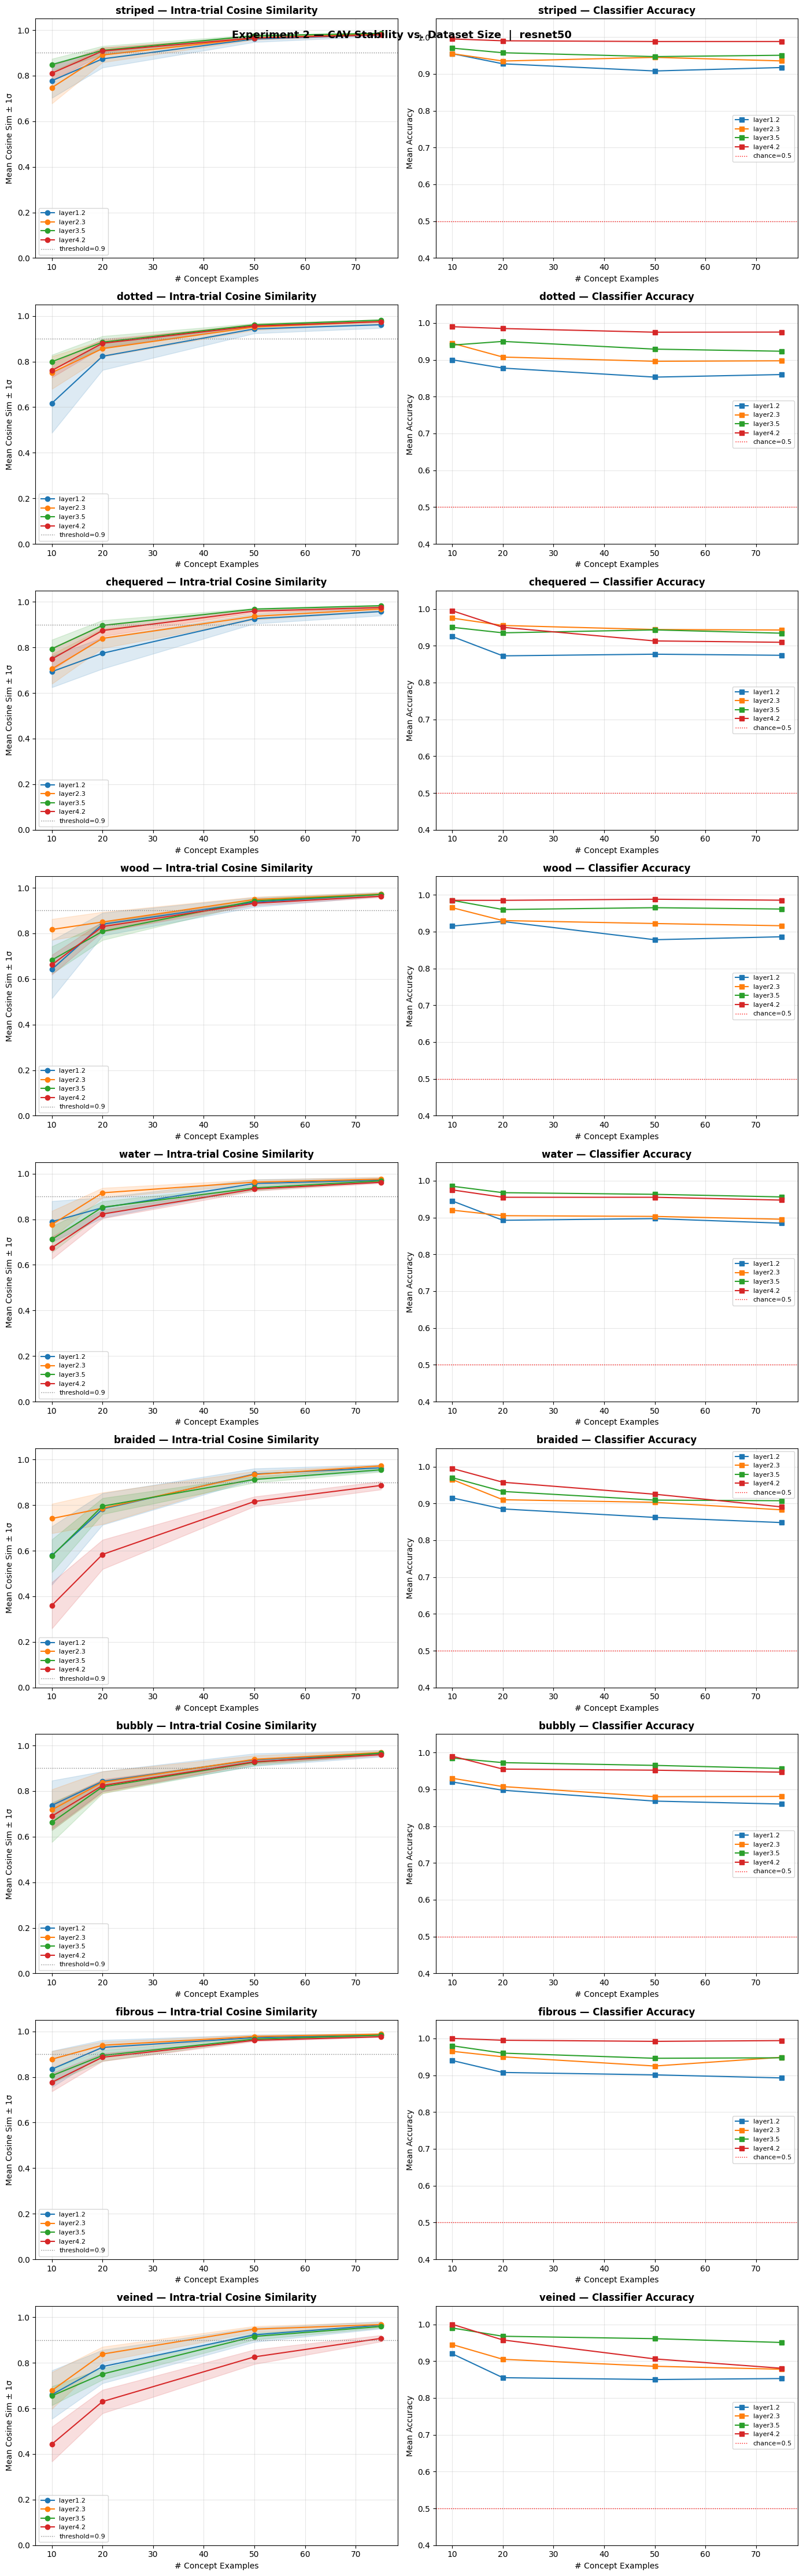

In [15]:
fig, axes = plt.subplots(
    len(cfg.concept_names), 2,
    figsize=(14, 5 * len(cfg.concept_names)),
)
fig.suptitle(
    f'Experiment 2 — CAV Stability vs. Dataset Size  |  {cfg.model_name}',
    fontsize=13, fontweight='bold',
)
layer_colors = dict(zip(cfg.target_layers, sns.color_palette('tab10')))

for i, concept in enumerate(cfg.concept_names):
    valid_sizes = exp2_results[concept]['valid_sizes']
    ax_sim = axes[i][0] if len(cfg.concept_names) > 1 else axes[0]
    ax_acc = axes[i][1] if len(cfg.concept_names) > 1 else axes[1]

    for layer in cfg.target_layers:
        ms  = exp2_results[concept]['mean_sim'][layer]
        ss  = exp2_results[concept]['std_sim'][layer]
        ma  = exp2_results[concept]['mean_acc'][layer]
        col = layer_colors[layer]
        ax_sim.plot(valid_sizes, ms, marker='o', label=layer, color=col)
        ax_sim.fill_between(valid_sizes,
                             np.array(ms) - np.array(ss),
                             np.array(ms) + np.array(ss),
                             alpha=0.15, color=col)
        ax_acc.plot(valid_sizes, ma, marker='s', label=layer, color=col)

    ax_sim.set_title(f'{concept} — Intra-trial Cosine Similarity', fontweight='bold')
    ax_sim.set_xlabel('# Concept Examples')
    ax_sim.set_ylabel('Mean Cosine Sim ± 1σ')
    ax_sim.set_ylim([0, 1.05])
    ax_sim.axhline(0.9, color='gray', linestyle=':', lw=1, label='threshold=0.9')
    ax_sim.legend(fontsize=8)
    ax_sim.grid(alpha=0.3)

    ax_acc.set_title(f'{concept} — Classifier Accuracy', fontweight='bold')
    ax_acc.set_xlabel('# Concept Examples')
    ax_acc.set_ylabel('Mean Accuracy')
    ax_acc.set_ylim([0.4, 1.05])
    ax_acc.axhline(0.5, color='red', linestyle=':', lw=1, label='chance=0.5')
    ax_acc.legend(fontsize=8)
    ax_acc.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/exp2_dataset_size_stability.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Convergence Study — Knee/Elbow (CAV vs. number of samples)

Plot imported from the CAV sample-size convergence study. It determines the minimum number of
concept images needed for a **stable CAV**, i.e. the point beyond which adding more images no
longer changes the CAV direction appreciably.

- **Stability** — mean cosine similarity across bootstrap CAVs at fixed `N` (rises and saturates).
- **Convergence** — cosine between the mean CAV at `N` and the full-pool CAV (dotted line = threshold).
- **Incremental variation** — `1 - cos(N, N-1)`, on a log scale.

Dashed vertical lines mark the knee (Kneedle) per layer; the grey band is the oversampling region.
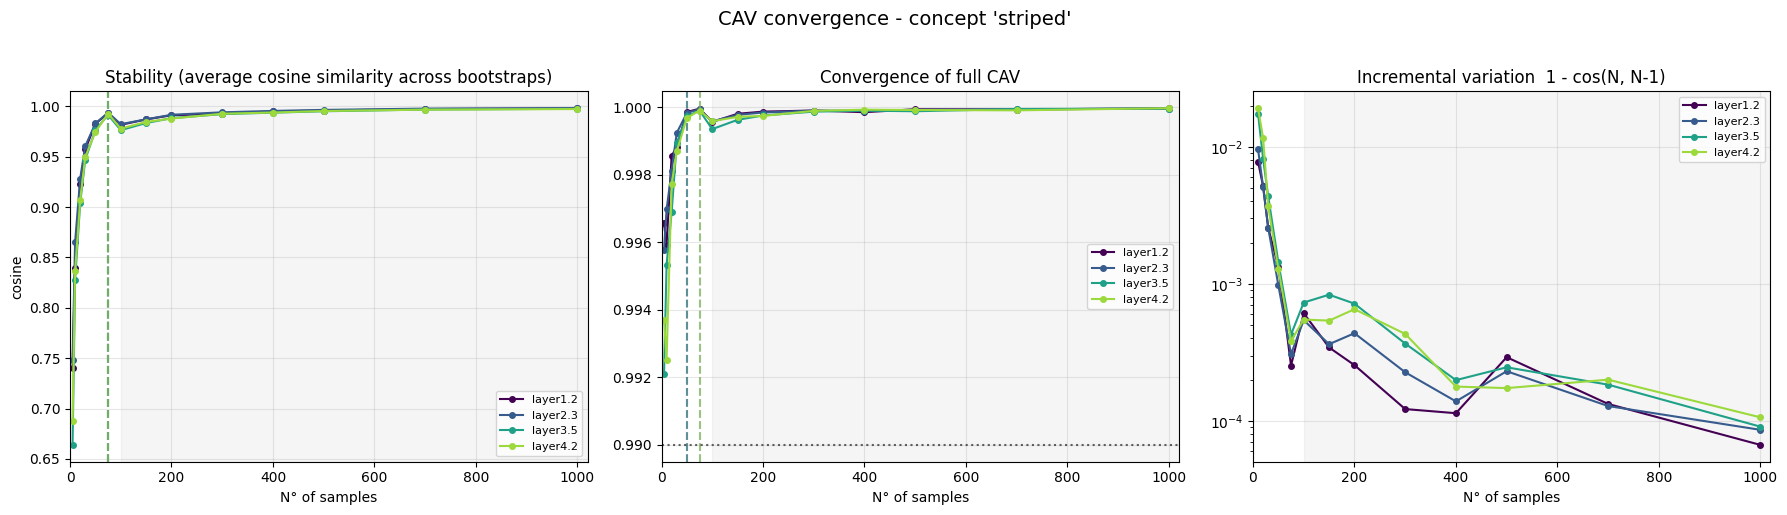

---
## Experiment 3 — Intra-Similarity

In [16]:
print('EXPERIMENT 3 - Intra-Similarity')

exp4_results = {
    c: {l: {'cavs': [], 'sim_matrix': None} for l in cfg.target_layers}
    for c in cfg.concept_names
}

for concept in cfg.concept_names:
    max_pos = len(concept_acts[concept][cfg.target_layers[0]])
    max_neg = len(negative_acts[cfg.target_layers[0]])
    pos_m = min(cfg.n_concept_samples,  max_pos - 1)   # m < N
    neg_m = min(cfg.n_negative_samples, max_neg - 1)   # m < N
    if pos_m < 2 or neg_m < 2:
        print(f'  WARN {concept}: pool troppo piccolo (pos={max_pos}, neg={max_neg}); '
              f'intra-similarity poco informativa.')
        pos_m = max(2, pos_m); neg_m = max(2, neg_m)

    for _ in tqdm(range(cfg.n_intra_trials), desc=f'  {concept}', leave=False):
        pos_idx = np.random.choice(max_pos, size=pos_m, replace=False)
        neg_idx = np.random.choice(max_neg, size=neg_m, replace=False)
        for layer in cfg.target_layers:
            cav, _ = train_cav(
                concept_acts[concept][layer][pos_idx],
                negative_acts[layer][neg_idx],
                cfg.cav_classifier,
                scaler=negative_scalers[layer],
            )
            exp4_results[concept][layer]['cavs'].append(cav)

for concept in cfg.concept_names:
    for layer in cfg.target_layers:
        cavs = exp4_results[concept][layer]['cavs']
        n    = len(cavs)
        mat  = np.array([[cosine_similarity(cavs[a], cavs[b])
                          for b in range(n)] for a in range(n)])
        exp4_results[concept][layer]['sim_matrix'] = mat

print('\nExp 3 - Mean off-diagonal cosine similarity:')
print(f'{"Concept":<14}', end='')
for l in cfg.target_layers:
    print(f'{l:>22}', end='')
print()
for concept in cfg.concept_names:
    print(f'{concept:<14}', end='')
    for layer in cfg.target_layers:
        mat = exp4_results[concept][layer]['sim_matrix'].copy()
        np.fill_diagonal(mat, np.nan)
        print(f'{np.nanmean(mat):>22.4f}', end='')
    print()


EXPERIMENT 3 - Intra-Similarity


  striped:   0%|          | 0/30 [00:00<?, ?it/s]

  dotted:   0%|          | 0/30 [00:00<?, ?it/s]

  chequered:   0%|          | 0/30 [00:00<?, ?it/s]

  wood:   0%|          | 0/30 [00:00<?, ?it/s]

...

  braided:   0%|          | 0/30 [00:00<?, ?it/s]

  bubbly:   0%|          | 0/30 [00:00<?, ?it/s]

  fibrous:   0%|          | 0/30 [00:00<?, ?it/s]

  veined:   0%|          | 0/30 [00:00<?, ?it/s]


Exp 3 - Mean off-diagonal cosine similarity:
Concept                     layer1.2              layer2.3              layer3.5              layer4.2
striped                       0.9253                0.9355                0.9436                0.9351
dotted                        0.8629                0.9120                0.9310                0.9185
chequered                     0.8615                0.9006                0.9348                0.9175
wood                          0.8574                0.8901                0.8892                0.8795
water                         0.8966                0.9242                0.8801                0.8743
braided                       0.8526                0.8761                0.8396                0.6781
bubbly                        0.8921                0.8998                0.8867                0.8736
fibrous                       0.9479                0.9556                0.9330                0.9246
veined                     

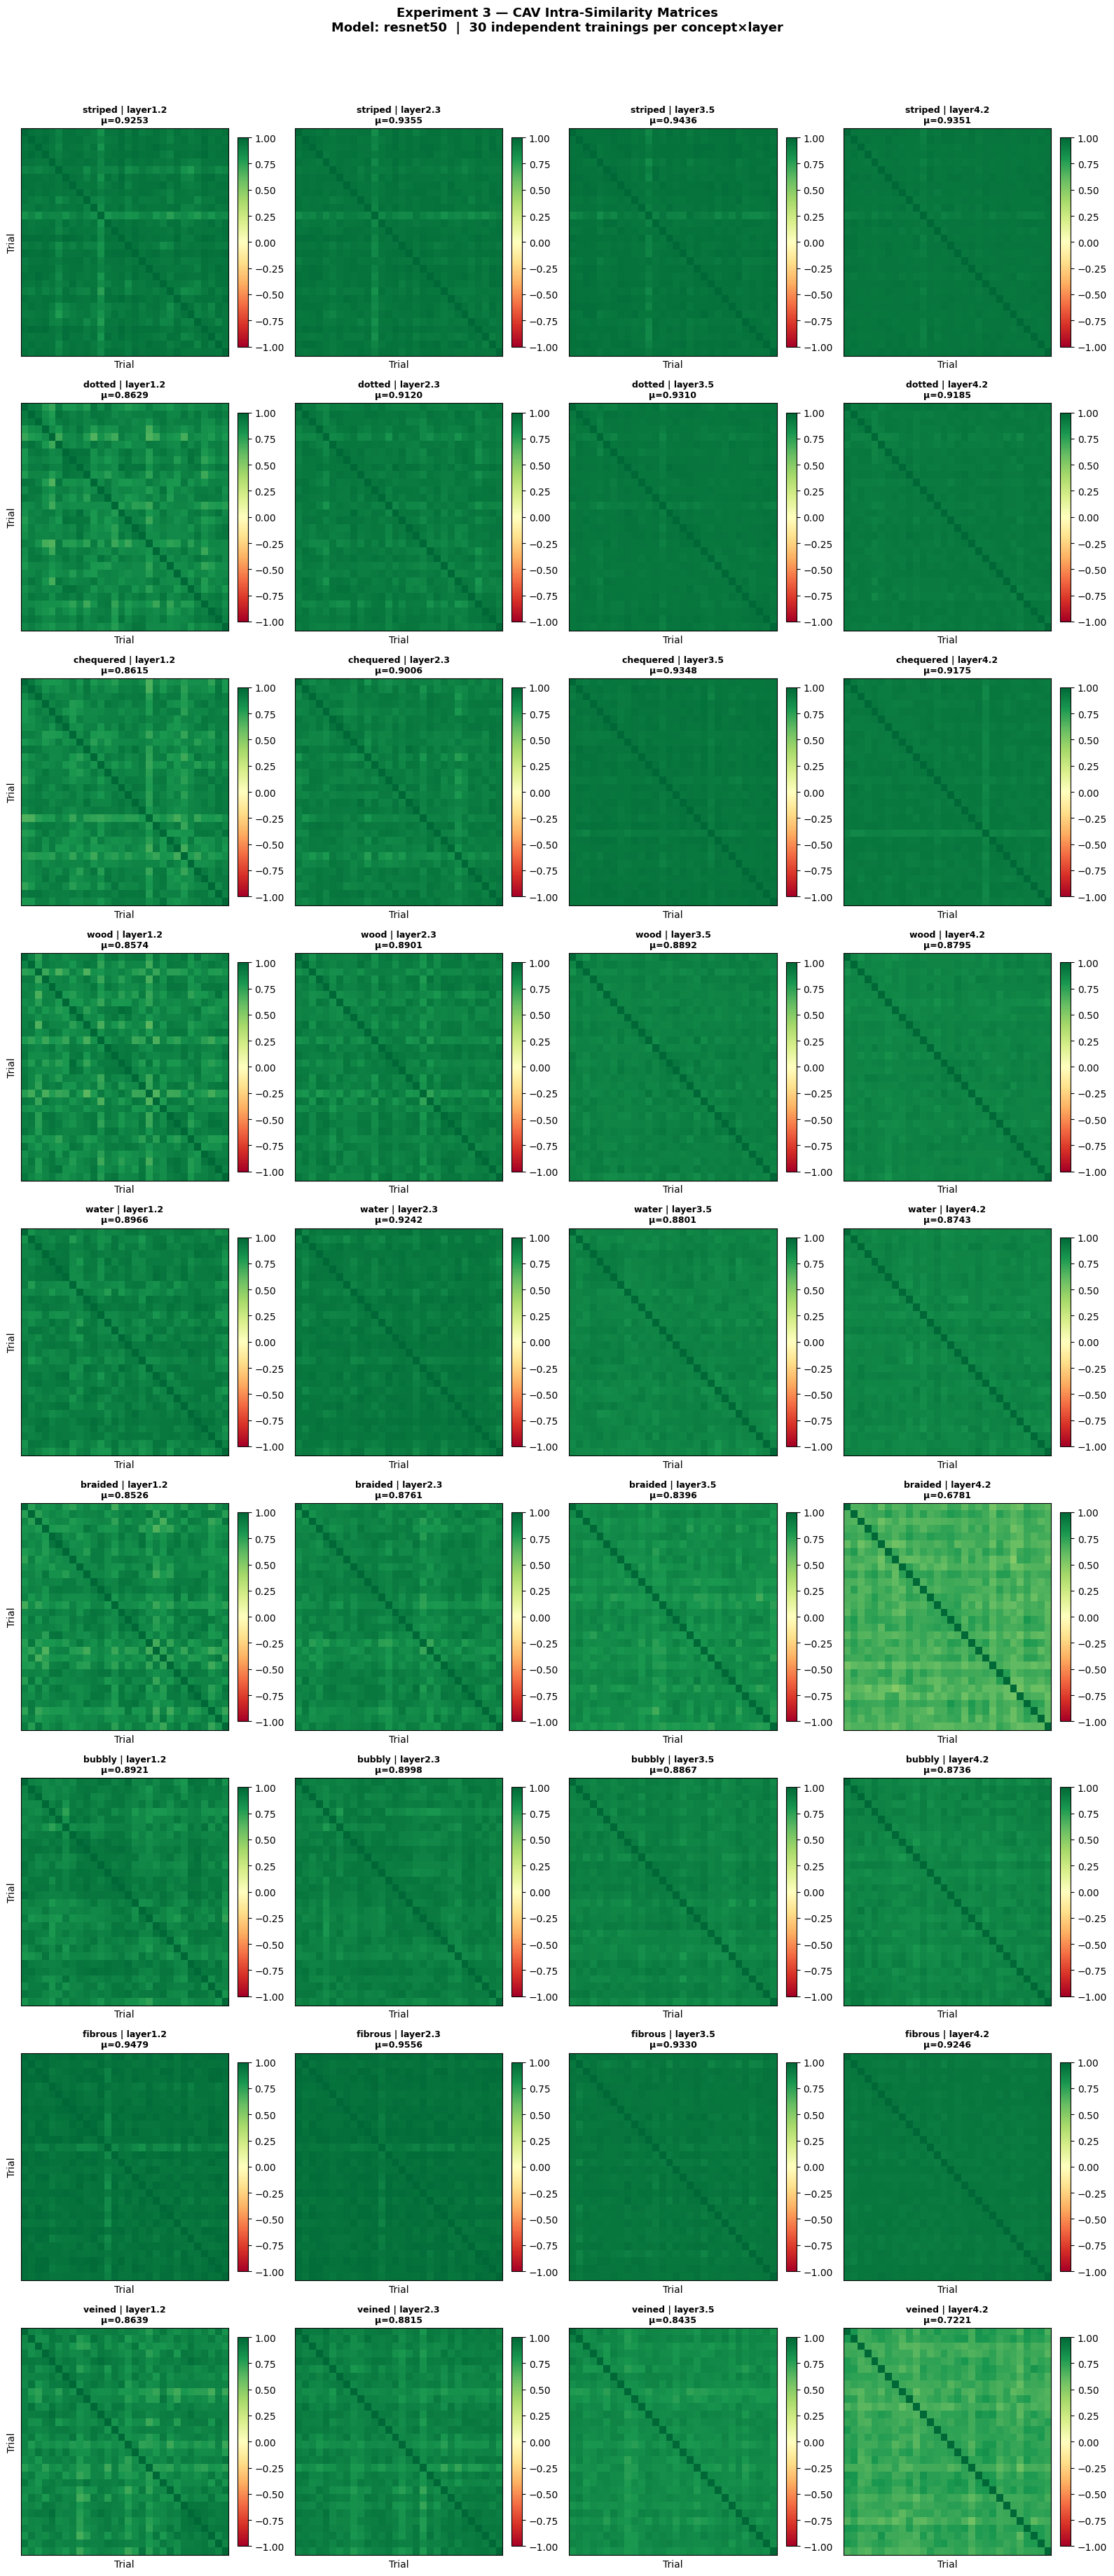

In [17]:
n_concepts = len(cfg.concept_names)
n_layers   = len(cfg.target_layers)

fig, axes = plt.subplots(n_concepts, n_layers,
                          figsize=(4 * n_layers, 4 * n_concepts),
                          squeeze=False)
fig.suptitle(
    f'Experiment 3 — CAV Intra-Similarity Matrices\n'
    f'Model: {cfg.model_name}  |  {cfg.n_intra_trials} independent trainings per concept×layer',
    fontsize=13, fontweight='bold', y=1.02,
)

for i, concept in enumerate(cfg.concept_names):
    for j, layer in enumerate(cfg.target_layers):
        ax  = axes[i][j]
        mat = exp4_results[concept][layer]['sim_matrix'].copy()
        np.fill_diagonal(mat, 1.0)
        im  = ax.imshow(mat, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        off = mat[~np.eye(mat.shape[0], dtype=bool)]
        ax.set_title(f'{concept} | {layer}\nμ={off.mean():.4f}',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Trial')
        ax.set_ylabel('Trial' if j == 0 else '')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('/kaggle/working/exp3_intra_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
import json

RUN_KEY = '|'.join([
    cfg.model_name, cfg.cav_classifier, ACTIVE_DATASET_TYPE,
    ACTIVE_CROP, ACTIVE_SPLIT, cfg.negative_source, f'std={cfg.standardize}',
])

summary = {
    'config': {
        'model_name': cfg.model_name, 'cav_classifier': cfg.cav_classifier,
        'dataset_type': ACTIVE_DATASET_TYPE, 'crop': ACTIVE_CROP, 'split': ACTIVE_SPLIT,
        'negative_source': cfg.negative_source, 'standardize': cfg.standardize,
        'n_concepts': len(cfg.concept_names), 'concepts': cfg.concept_names,
    },
    'exp1_mean_per_layer': {
        l: float(np.mean([exp1_similarity[c][l].mean() for c in cfg.concept_names]))
        for l in cfg.target_layers
    },
    'exp1_std_per_layer': {
        l: float(np.std([exp1_similarity[c][l].mean() for c in cfg.concept_names]))
        for l in cfg.target_layers
    },
}
# Exp 3 (se gia' eseguito)
try:
    def _offdiag_mean(concept, layer):
        m = exp4_results[concept][layer]['sim_matrix'].copy()
        np.fill_diagonal(m, np.nan)
        return float(np.nanmean(m))
    summary['exp3_mean_per_layer'] = {
        l: float(np.mean([_offdiag_mean(c, l) for c in cfg.concept_names]))
        for l in cfg.target_layers
    }
except NameError:
    pass

STORE = '/kaggle/working/stability_runs.json'
runs = json.loads(Path(STORE).read_text()) if Path(STORE).exists() else {}
runs[RUN_KEY] = summary
Path(STORE).write_text(json.dumps(runs, indent=2))
print(f'Saved run: {RUN_KEY}')
print(f'Totale run memorizzati in {STORE}: {len(runs)}')

Saved run: resnet50|difference_of_means|vanilla|sliding_window|single|imagenet|std=True
Totale run memorizzati in /kaggle/working/stability_runs.json: 1
